In [ ]:
# Use the list of cities to create site inputs for openeo
# Download sentinel-2 assets based on time, cloudcover and image quality
# Add band math operations
# https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel/sentinel-2/

# Updated helper files: prepare_openeo.py, utlilities.py
# RTS, May 16 - 20, 2025
# Reused July 9, 2025 to test open mine sites
# Updated July 28, 2025 to test open mine sites, 200 entries, tab separated
# update the prepare_openeo.py get_sites function


In [1]:
# variables specific to your CoLabsetup ----------------------------------------
from google.colab import drive
import os, sys
drive.mount('/content/drive')
root = '/content/drive/MyDrive/'
sys.path.append(root +"Colab/research/code/")
datapath = root + "Colab/research/data/"
datapathnudge = root + "Projects/Nudge-X/geo_images/samples/"
datapathcities = root + "Projects/Nudge-X/sites/"
datapathmines = root + "Projects/Nudge-X/sites/"

Mounted at /content/drive


In [2]:
# install packages
%%capture
!pip install openeo --upgrade
!pip install gdal
!pip install rasterio --upgrade
!pip install scikit-image --upgrade

In [3]:
# imports
import openeo, json
import rasterio, numpy
from rasterio.plot import show

# home brew
from prepare_openeo import *
from qualcheck_module import *
from utilities import *

In [4]:
# City names / mining sites and GPS coordinates
#collection = "Capital_Cities_with_Countries_and_Coordinates_update5.csv"
#collection = "Open_Mines_Coordinates_v3.csv"

collection = "Open_Mines_Coordinates_v5.tsv"
file_path = datapathmines + collection

In [5]:
category = "mines" #"cities
#cities, bboxes = get_sites_org(file_path, category, limit=20)
delimiter = '\t'
cities, bboxes = get_sites(file_path, category, delimiter, limit=20)

print(cities)
print(bboxes)

i = 0
for item in cities:
    print (i, item)
    i = i+1

['RedLakeMines', 'CrowsNestPass', 'KingsMountainLithiumMine', 'BeauvoirQuarry', 'KalongweDeposit', 'MutshatshaMine', 'KolweziMine', 'FimistonOpenPit', 'TancoMine', 'FooteLithiumMine', 'KoktokayAltayMIne', 'BurangaMine', 'AidyrlaGoldDeposit', 'NovyiAidyrlinskiiMine', 'BishaMine', 'ImourarenUraniumMine', 'HoucaoBauxiteDeposit', 'TsumebMine', 'KoashvaQuarry', 'BuckwheatPit']
[[-93.8212626441203, 51.10902708029594, -93.67816135587971, 51.01909491970407], [-114.7451608789667, 49.679805080295935, -114.60630312103329, 49.589872919704064], [-81.40893372473143, 35.267746080295936, -81.29884627526859, 35.177813919704064], [2.8889284440116643, 46.22390608029593, 3.018811555988336, 46.13397391970406], [25.1803007543293, -10.971422919704064, 25.2719212456707, -11.061355080295936], [25.34821328302438, -10.668064919704065, 25.43974071697562, -10.757997080295937], [25.410254084467486, -10.682603919704064, 25.501785915532512, -10.772536080295936], [121.45312281064093, -30.732505919704064, 121.557797189

In [ ]:
# Connect to the cdse backend
# marcbohlen@gmail	!2EU ... EU2!
connection = openeo.connect(url="openeo.dataspace.copernicus.eu")

#authenticate with your Copernicus credentials
connection.authenticate_oidc()
print()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=OLRE-UVBV 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.



In [ ]:
# Make the start time variable depending on whether the first attempt returned a viable result

satellite = "SENTINEL2_L1C"
max_cloud = 5
start = "2024-11-01"    #change the start date if you cant find anything in starting November
end = "2024-12-31"
band_selection = ["B12", "B08", "B04", "B03", "B02"]

#OK
#aspect = "rgb"
#aspect = "ndvi"
#aspect = "nbr"
#aspect = "ndbi"
#aspect = "fmi"

aspect = "rgb"
job_title = "nudge_" + aspect

In [ ]:
## ------------------------------------------------------------------------------------------------------------------------------------------
# get just one of the items and create a job for OpenEO
## ------------------------------------------------------------------------------------------------------------------------------------------
# create_job_type is a function in "prepare_openeo.py" (in the code directory)
index = 13
bbox_s = bboxes[index]
city_s = cities[index]
job = create_job_type(connection, bbox_s, start, end, satellite, band_selection, max_cloud, job_title, aspect)

print(job_title)
print("SITE: ", city_s)
print("TIMEFRAME: ", start, end)
print(connection.list_jobs())

nudge_rgb
SITE:  NovyiAidyrlinskiiMine
TIMEFRAME:  2024-10-01 2024-12-31
[{'created': '2025-07-23T19:50:57Z', 'id': 'j-2507231950574a1e9d3e7d25f8eaf61c', 'progress': 100, 'status': 'finished', 'title': 'nudge_rgb', 'updated': '2025-07-23T19:54:09Z'}, {'created': '2025-07-23T19:47:14Z', 'id': 'j-250723194714433a983990a9c27577b4', 'progress': 100, 'status': 'finished', 'title': 'nudge_rgb', 'updated': '2025-07-23T19:49:08Z'}, {'created': '2025-07-23T19:39:58Z', 'id': 'j-2507231939584e3aa7eccea7784a1a97', 'progress': 100, 'status': 'finished', 'title': 'nudge_rgb', 'updated': '2025-07-23T19:43:09Z'}, {'created': '2025-07-23T19:35:39Z', 'id': 'j-2507231935394c909bae5d22ea95019a', 'progress': 100, 'status': 'finished', 'title': 'nudge_rgb', 'updated': '2025-07-23T19:37:11Z'}, {'created': '2025-07-23T19:30:45Z', 'id': 'j-2507231930454a9cbf79e7546e0730d9', 'progress': 100, 'status': 'finished', 'title': 'nudge_rgb', 'updated': '2025-07-23T19:33:14Z'}, {'created': '2025-07-23T19:28:21Z', 'id':

In [ ]:
try:
    job.start_and_wait()
except:
    print("something went wrong")

0:00:00 Job 'j-25072319564646f6a211b62002b268bc': send 'start'
0:00:12 Job 'j-25072319564646f6a211b62002b268bc': created (progress 0%)
0:00:18 Job 'j-25072319564646f6a211b62002b268bc': created (progress 0%)
0:00:24 Job 'j-25072319564646f6a211b62002b268bc': running (progress N/A)
0:00:32 Job 'j-25072319564646f6a211b62002b268bc': running (progress N/A)
0:00:42 Job 'j-25072319564646f6a211b62002b268bc': running (progress N/A)
0:00:54 Job 'j-25072319564646f6a211b62002b268bc': running (progress N/A)
0:01:10 Job 'j-25072319564646f6a211b62002b268bc': running (progress N/A)
0:01:29 Job 'j-25072319564646f6a211b62002b268bc': finished (progress 100%)


In [ ]:
# Tally results and filter them. Check prepare_openeo.py
results = job.get_results()
metadata = results.get_metadata()
metadata['assets'].keys()

compiled = recompile(metadata)
res = filter(compiled)
print(compiled)
print(res)

{'openEO_2024-10-05Z.tif': {'B04': 98.41, 'B03': 98.41, 'B02': 98.41}, 'openEO_2024-10-15Z.tif': {'B04': 98.41, 'B03': 98.41, 'B02': 98.41}, 'openEO_2024-11-24Z.tif': {'B04': 98.41, 'B03': 98.41, 'B02': 98.41}, 'openEO_2024-11-29Z.tif': {'B04': 98.41, 'B03': 98.41, 'B02': 98.41}}
['openEO_2024-10-05Z.tif', 'openEO_2024-10-15Z.tif', 'openEO_2024-11-24Z.tif', 'openEO_2024-11-29Z.tif']


In [ ]:
# Check the filtered list against the assets -
relevant_results = []

assets = results.get_assets()
for item in assets:
    for filtered in res:
        if(item.name == filtered):
            relevant_results.append(item)

# check
#print(relevant_results)

#prune to get only the latest one...
latest_result = relevant_results[-1]
print("------")
print(latest_result)

------
<ResultAsset 'openEO_2024-11-29Z.tif' (type image/tiff; application=geotiff) at 'https://openeo.dataspace.copernicus.eu/openeo/1.2/jobs/j-25072319564646f6a211b62002b268bc/results/assets/ZTJjNjI3YjktMWQxNS00NDZlLWE4NDMtOWU3ZWIzYjExMDhh/5311452e68500607446584a43d6fd859/openEO_2024-11-29Z.tif?expires=1753905560'>


In [ ]:
#download those files and name them based on image type (aspect in job_title), location and date
targets = []

#for item in relevant_results:
item = latest_result
date = item.name.split("openEO_")[1]
date = date.split("Z.tif")[0] + ".tif"
if("rgb" in job_title):
    target = city_s + "_rgb_" + date
elif("ndvi" in job_title):
    target = city_s + "_ndvi_" + date
elif("nbr" in job_title):
    target = city_s + "_nbr_" + date
elif("fmi" in job_title):
    target = city_s + "_fmi_" + date
elif("ndbi" in job_title):
    target = city_s + "_ndbi_" + date
else:
    target = city_s + "_" + date

targets.append(target)
item.download(datapathcities + target)

PosixPath('/content/drive/MyDrive/Projects/Nudge-X/sites/NovyiAidyrlinskiiMine_rgb_2024-11-29.tif')

In [ ]:
print(targets)

['NovyiAidyrlinskiiMine_rgb_2024-11-29.tif']


In [ ]:
# Check the quality of the downloaded assets first...Only for the RGB images... if it is ok, the others should be as well...
for thing in targets:
    stats = evaluate_image_quality (datapathcities + thing)
    print(stats)

{'contrast': np.float64(11.236074878757849), 'entropy': np.float64(72.09495457868448), 'sharpness': np.float64(2.9336573207047176), 'noise': np.float64(95.6086193291347), 'overall': np.float64(45.468326526820434)}


In [ ]:
# Pick one target to visualize here
# Make a loop to process them all...

# TEST
#test = "Islamabad_fmi_2025-01-24.tif"
#test = "Buenos Aires_rgb_2024-12-28.tif"
#file_path = datapathcities + test
#png_output_path = datapathcities + test.split(".tif")[0] + ".png"
#----------------------------------------------------------------
pick = 0
source = targets[pick]
file_path = datapathcities + source
png_output_path = datapathcities + source.split(".tif")[0] + ".png"
print(file_path)

/content/drive/MyDrive/Projects/Nudge-X/sites/NovyiAidyrlinskiiMine_rgb_2024-11-29.tif


In [ ]:
# Adjust visualization for human consumption. Attention to stretch_contast - it can exaggerate results of band operations !
# Stretch_contrast on rgb images
brightness_factor = 1.3
saturation_factor = 0.65   #(0.75)
stretch_contrast = True
rgb = adjust_coloration(file_path, job_title, stretch_contrast, brightness_factor, saturation_factor)

Saved color-corrected PNG to: /content/drive/MyDrive/Projects/Nudge-X/sites/NovyiAidyrlinskiiMine_rgb_2024-11-29.png


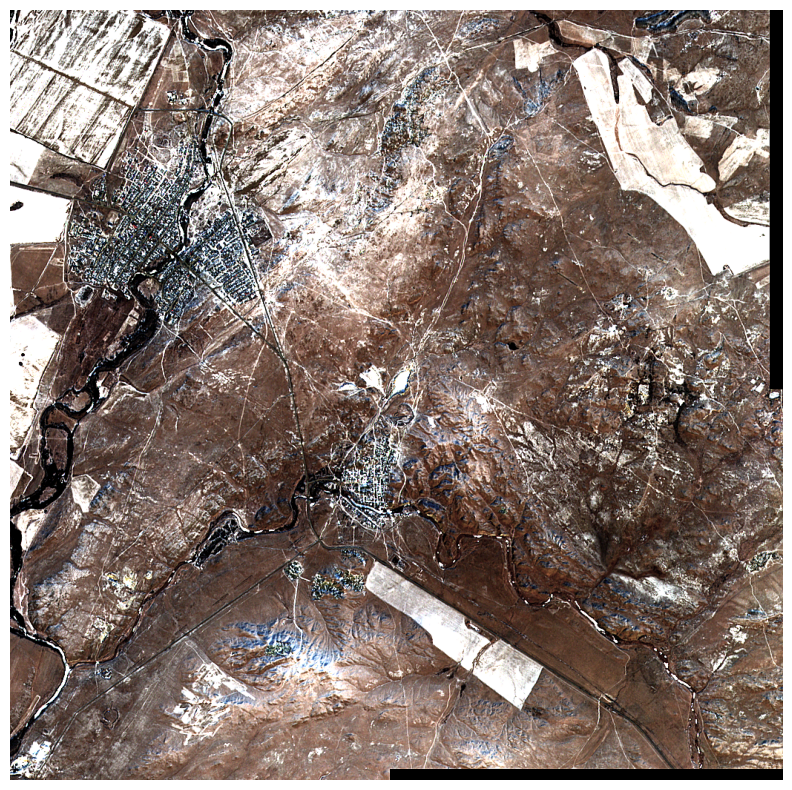

In [ ]:
# Display RGB / NDVI / NBR / NDBI /  FMI
import matplotlib.pyplot as plt

if rgb is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    #plt.imshow(rgb, vmin=-1, vmax=1)
    #plt.title("Color-Corrected GeoTIFF (RGB) of " +  target)
    plt.axis('off')
    plt.savefig(png_output_path, bbox_inches='tight', pad_inches=0)
    print(f"Saved color-corrected PNG to: {png_output_path}")
else:
    print(f"Skipping plotting for {source} as image data is None.")